# Best-Practices Handbook for Volatility Modeling

This handbook addresses common challenges in time series modeling relevant to financial volatility analysis. For each problem, we will cover its technical definition, a descriptive explanation, a numerical demonstration, a visual diagram, methods for diagnosis, the potential damage it can cause, and practical directions for mitigation.

## Table of Contents

1.  [Multicollinearity](#1-Multicollinearity)
    *   [Definition](#Definition)
    *   [Description](#Description)
    *   [Demonstration](#Demonstration)
    *   [Diagram](#Diagram)
    *   [Diagnosis](#Diagnosis)
    *   [Damage](#Damage)
    *   [Directions](#Directions)
2.  [Overfitting](#2-Overfitting)
    *   [Definition](#Definition_1)
    *   [Description](#Description_1)
    *   [Demonstration](#Demonstration_1)
    *   [Diagram](#Diagram_1)
    *   [Diagnosis](#Diagnosis_1)
    *   [Damage](#Damage_1)
    *   [Directions](#Directions_1)
3.  [Skewness](#3-Skewness)
    *   [Definition](#Definition_2)
    *   [Description](#Description_2)
    *   [Demonstration](#Demonstration_2)
    *   [Diagram](#Diagram_2)
    *   [Diagnosis](#Diagnosis_2)
    *   [Damage](#Damage_2)
    *   [Directions](#Directions_2)
4.  [Sensitivity to Outliers](#4-Sensitivity-to-Outliers)
    *   [Definition](#Definition_3)
    *   [Description](#Description_3)
    *   [Demonstration](#Demonstration_3)
    *   [Diagram](#Diagram_3)
    *   [Diagnosis](#Diagnosis_3)
    *   [Damage](#Damage_3)
    *   [Directions](#Directions_3)
5.  [Summary](#Summary)
6.  [References](#References)


## 1. Multicollinearity

### Definition
Multicollinearity occurs in multiple regression models when two or more independent variables are highly linearly related. If $X_j$ and $X_k$ are two independent variables, they are multicollinear if their correlation coefficient $ \rho_{X_j, X_k} $ approaches 1 or -1. More generally, it means one predictor variable can be linearly predicted from the others with a substantial degree of accuracy. For a linear regression model:

$ Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_p X_p + \epsilon $

Multicollinearity exists when there is a strong linear relationship among some or all of the predictor variables $X_1, \dots, X_p$.

### Description
Multicollinearity makes it difficult to ascertain the individual impact of each predictor variable on the dependent variable because their effects are intertwined. This can lead to unreliable estimates of the regression coefficients, making it hard to interpret the true relationships.

### Demonstration

In [2]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Simulate data with multicollinearity
np.random.seed(42)
num_samples = 100

# Generate a base predictor
X1 = np.random.rand(num_samples) * 10

# Generate a second predictor highly correlated with X1
X2 = X1 * 0.9 + np.random.rand(num_samples) * 2 # High correlation

# Generate a third independent predictor
X3 = np.random.rand(num_samples) * 5

# Generate the dependent variable (Y)
Y = 2 * X1 + 3 * X2 - 1 * X3 + np.random.randn(num_samples) * 5

df_multi = pd.DataFrame({'X1': X1, 'X2': X2, 'X3': X3, 'Y': Y})

# Fit a regression model
X = df_multi[['X1', 'X2', 'X3']]
X = sm.add_constant(X) # Add a constant term
model = sm.OLS(df_multi['Y'], X)
results = model.fit()

print("Regression results with multicollinearity:")
print(results.summary())

Regression results with multicollinearity:
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.900
Method:                 Least Squares   F-statistic:                     297.6
Date:                Wed, 06 May 2026   Prob (F-statistic):           1.80e-48
Time:                        10:51:20   Log-Likelihood:                -299.12
No. Observations:                 100   AIC:                             606.2
Df Residuals:                      96   BIC:                             616.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const    

Notice the high standard errors and p-values for `X1` and `X2`, despite them being used to generate `Y`. The coefficients might also be counter-intuitive or have large changes with small data adjustments.

### Diagram

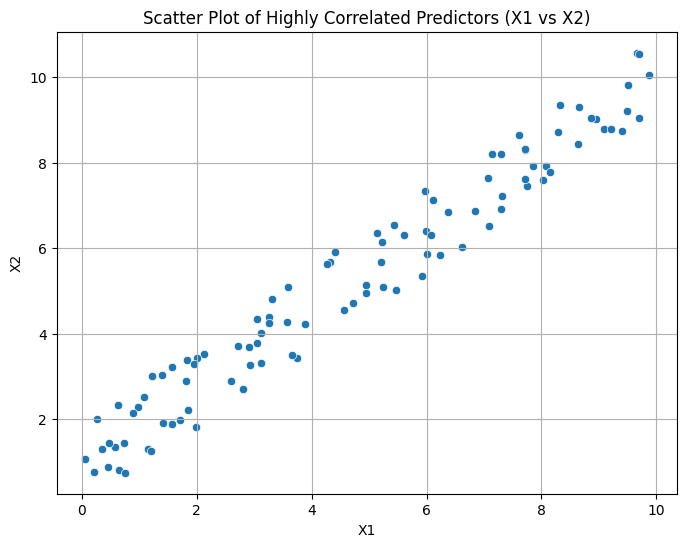

In [3]:
# Ensure 'df_multi' is defined by running the "Demonstration" cell (above) first.
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x=df_multi['X1'], y=df_multi['X2'])
plt.title('Scatter Plot of Highly Correlated Predictors (X1 vs X2)')
plt.xlabel('X1')
plt.ylabel('X2')
plt.grid(True)
plt.show()

The clear linear pattern in the scatter plot visually indicates multicollinearity between `X1` and `X2`.

### Diagnosis

Variance Inflation Factor (VIF):
  Features        VIF
0    const  11.112919
1       X1  21.982997
2       X2  22.055546
3       X3   1.023792

Correlation Matrix:
          X1        X2        X3
X1  1.000000  0.976549 -0.037654
X2  0.976549  1.000000 -0.068575
X3 -0.037654 -0.068575  1.000000


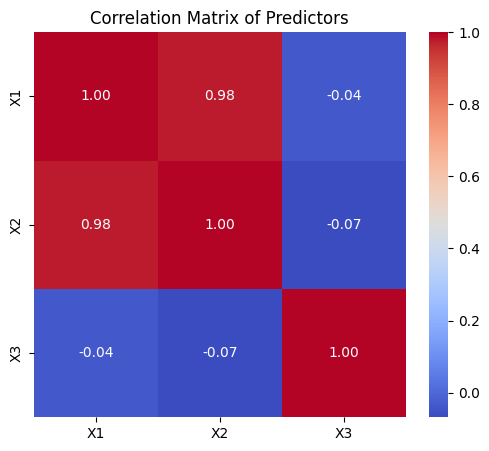

In [4]:
# Ensure 'X' and 'df_multi' are defined by running the "Demonstration" cell (above) first.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate Variance Inflation Factor (VIF)
vifs = pd.DataFrame()
vifs['Features'] = X.columns
vifs['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print("Variance Inflation Factor (VIF):")
print(vifs)

correlation_matrix = df_multi[['X1', 'X2', 'X3']].corr()
print("\nCorrelation Matrix:")
print(correlation_matrix)

plt.figure(figsize=(6, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Predictors')
plt.show()

A VIF value greater than 5 or 10 is often considered indicative of significant multicollinearity. The correlation matrix also clearly shows the strong correlation between `X1` and `X2`.

### Damage
Multicollinearity leads to large standard errors of the regression coefficients, making them statistically insignificant even when the underlying predictor has a true effect. It also makes coefficient estimates highly sensitive to small changes in the model or data, hindering interpretability and stability.

### Directions
1.  **Remove one of the highly correlated variables**: If two variables convey similar information, consider dropping one, especially if one is theoretically less relevant or harder to obtain.
2.  **Combine variables**: Create a new composite variable from the correlated ones (e.g., an average or sum), if meaningful.
3.  **Use regularization methods**: Techniques like Ridge Regression (L2 regularization) can shrink regression coefficients towards zero, reducing their variance and stabilizing estimates in the presence of multicollinearity.
4.  **Principal Component Analysis (PCA)**: Transform the highly correlated predictors into a set of uncorrelated principal components, which can then be used in the regression model.
5.  **Increase sample size**: Sometimes, with more data, the stability of coefficient estimates improves, but this isn't always feasible or a guaranteed fix.

## 2. Overfitting

### Definition
Overfitting occurs when a statistical model learns the training data too well, including the noise and random fluctuations, to the detriment of its ability to generalize to new, unseen data. While the model shows high accuracy on the training data, its performance on validation or test data is significantly poorer. Mathematically, for a model $f(x)$ trained on data $(X_{train}, Y_{train})$ and evaluated on test data $(X_{test}, Y_{test})$, overfitting is indicated when $Error(f(X_{train}, Y_{train})) \ll Error(f(X_{test}, Y_{test}))$.

### Description
An overfit model captures spurious patterns specific to the training set rather than the underlying true relationship, making it overly complex and not robust for predictions on new data. It essentially memorizes the training examples instead of learning the general principles.

### Demonstration

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

# Simulate data with a non-linear underlying relationship and noise
np.random.seed(0)
X = np.sort(5 * np.random.rand(80, 1), axis=0)
Y = np.sin(X).ravel() + np.random.normal(0, 0.5, X.shape[0])

# Split data into training and test sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

# --- Underfit Model (Linear Regression) ---
linear_model = LinearRegression()
linear_model.fit(X_train, Y_train)

Y_train_pred_linear = linear_model.predict(X_train)
Y_test_pred_linear = linear_model.predict(X_test)

rmse_train_linear = np.sqrt(mean_squared_error(Y_train, Y_train_pred_linear))
rmse_test_linear = np.sqrt(mean_squared_error(Y_test, Y_test_pred_linear))

print(f"\n--- Underfit Model (Linear Regression) ---")
print(f"Train RMSE: {rmse_train_linear:.3f}")
print(f"Test RMSE:  {rmse_test_linear:.3f}")

# --- Overfit Model (High-degree Polynomial Regression) ---
polynomial_features_overfit = PolynomialFeatures(degree=15, include_bias=False)
X_train_poly_overfit = polynomial_features_overfit.fit_transform(X_train)
X_test_poly_overfit = polynomial_features_overfit.transform(X_test)

poly_model_overfit = LinearRegression()
poly_model_overfit.fit(X_train_poly_overfit, Y_train)

Y_train_pred_poly_overfit = poly_model_overfit.predict(X_train_poly_overfit)
Y_test_pred_poly_overfit = poly_model_overfit.predict(X_test_poly_overfit)

rmse_train_poly_overfit = np.sqrt(mean_squared_error(Y_train, Y_train_pred_poly_overfit))
rmse_test_poly_overfit = np.sqrt(mean_squared_error(Y_test, Y_test_pred_poly_overfit))

print(f"\n--- Overfit Model (Polynomial Regression, degree=15) ---")
print(f"Train RMSE: {rmse_train_poly_overfit:.3f}")
print(f"Test RMSE:  {rmse_test_poly_overfit:.3f}")

# --- "Good Fit" Model (Moderate-degree Polynomial Regression) ---
polynomial_features_good = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly_good = polynomial_features_good.fit_transform(X_train)
X_test_poly_good = polynomial_features_good.transform(X_test)

poly_model_good = LinearRegression()
poly_model_good.fit(X_train_poly_good, Y_train)

Y_train_pred_poly_good = poly_model_good.predict(X_train_poly_good)
Y_test_pred_poly_good = poly_model_good.predict(X_test_poly_good)

rmse_train_poly_good = np.sqrt(mean_squared_error(Y_train, Y_train_pred_poly_good))
rmse_test_poly_good = np.sqrt(mean_squared_error(Y_test, Y_test_pred_poly_good))

print(f"\n--- Good Fit Model (Polynomial Regression, degree=3) ---")
print(f"Train RMSE: {rmse_train_poly_good:.3f}")
print(f"Test RMSE:  {rmse_test_poly_good:.3f}")


--- Underfit Model (Linear Regression) ---
Train RMSE: 0.707
Test RMSE:  0.730

--- Overfit Model (Polynomial Regression, degree=15) ---
Train RMSE: 0.425
Test RMSE:  0.545

--- Good Fit Model (Polynomial Regression, degree=3) ---
Train RMSE: 0.457
Test RMSE:  0.466


Notice that the highly complex (degree 15 polynomial) model achieves a very low RMSE on the training data but performs much worse on the test data. This is a classic sign of overfitting. The simple linear model underfits (high error on both train and test), while the degree 3 polynomial offers a better balance.

### Diagram

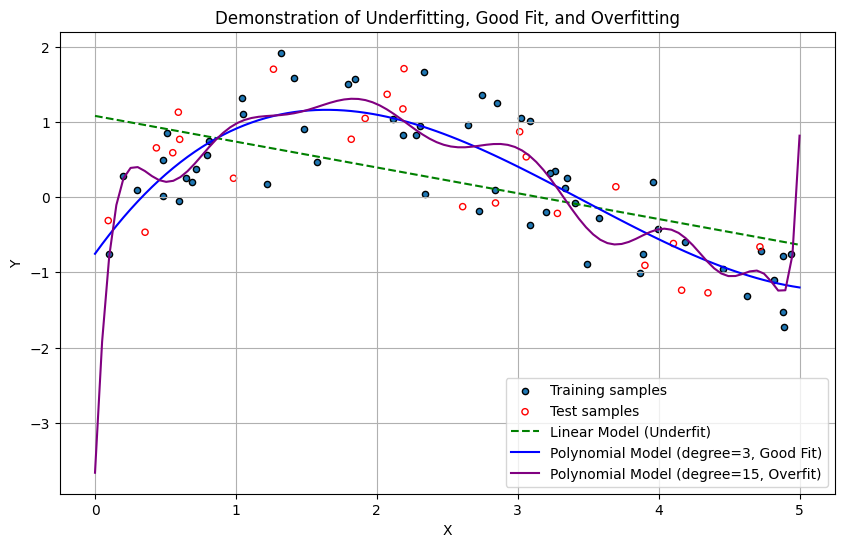

In [6]:
# Ensure X_train, Y_train, X_test, Y_test, linear_model, poly_model_good, poly_model_overfit are defined from the demonstration cell above.
# Also ensure polynomial_features_good and polynomial_features_overfit are defined.

plt.figure(figsize=(10, 6))
plt.scatter(X_train, Y_train, s=20, edgecolor="black", label="Training samples")
plt.scatter(X_test, Y_test, s=20, edgecolor="red", facecolor="none", label="Test samples")

X_plot = np.linspace(0, 5, 100).reshape(-1, 1)

# Plot linear model
plt.plot(X_plot, linear_model.predict(X_plot), color="green", linestyle='--', label="Linear Model (Underfit)")

# Plot good fit polynomial model
plt.plot(X_plot, poly_model_good.predict(polynomial_features_good.transform(X_plot)), color="blue", label="Polynomial Model (degree=3, Good Fit)")

# Plot overfit polynomial model
plt.plot(X_plot, poly_model_overfit.predict(polynomial_features_overfit.transform(X_plot)), color="purple", label="Polynomial Model (degree=15, Overfit)")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Demonstration of Underfitting, Good Fit, and Overfitting")
plt.legend()
plt.grid(True)
plt.show()

The diagram visually distinguishes between the models: the linear model is too simple (underfit), the degree 3 polynomial captures the underlying curve well (good fit), and the degree 15 polynomial is highly complex, trying to fit every data point, including noise, resulting in poor generalization (overfit).

### Diagnosis

In [7]:
# Ensure X_train, Y_train, X_test, Y_test are defined from the demonstration cell above.
# Also ensure polynomial_features_overfit and poly_model_overfit are defined.

# 1. Performance comparison on Training vs. Test Set
print("\n--- Diagnosis: Training vs. Test Performance ---")
print(f"Overfit Model Train RMSE: {rmse_train_poly_overfit:.3f}")
print(f"Overfit Model Test RMSE:  {rmse_test_poly_overfit:.3f}")

if rmse_test_poly_overfit > rmse_train_poly_overfit * 1.5: # Arbitrary threshold for demonstration
    print("Severe discrepancy between train and test performance suggests overfitting.")
else:
    print("Train and test performance are relatively close.")

# 2. Learning Curves (Conceptual example)
# While not generating actual learning curves here due to complexity for a single cell,
# the principle involves plotting model performance (e.g., error) on both the training
# set and a cross-validation set as a function of the training set size or model complexity.
# A large gap between training and validation error indicates high variance (overfitting).

# 3. Cross-Validation (Conceptual example)
from sklearn.model_selection import KFold, cross_val_score

print("\n--- Diagnosis: Cross-Validation (conceptual) ---")

# Create polynomial features for the overfit model degree (e.g., 15)
polynomial_features_cv = PolynomialFeatures(degree=15, include_bias=False)
X_poly_cv = polynomial_features_cv.fit_transform(X)

# Use cross-validation to assess generalization performance
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(LinearRegression(), X_poly_cv, Y, cv=kf, scoring='neg_root_mean_squared_error')

print(f"Cross-Validation RMSEs (degree=15): {[-s for s in cv_scores]}")
print(f"Mean CV RMSE (degree=15): {np.mean([-s for s in cv_scores]):.3f}")

# Compare with the train RMSE of the overfit model
print(f"Overfit Model Train RMSE: {rmse_train_poly_overfit:.3f}")

if np.mean([-s for s in cv_scores]) > rmse_train_poly_overfit * 1.2: # Arbitrary threshold
    print("High mean CV RMSE compared to training RMSE confirms overfitting.")
else:
    print("Cross-validation indicates reasonable generalization.")


--- Diagnosis: Training vs. Test Performance ---
Overfit Model Train RMSE: 0.425
Overfit Model Test RMSE:  0.545
Train and test performance are relatively close.

--- Diagnosis: Cross-Validation (conceptual) ---
Cross-Validation RMSEs (degree=15): [np.float64(0.5556303456816004), np.float64(0.7293457204074318), np.float64(0.519182468366149), np.float64(0.6558940537626858), np.float64(0.5004202813590574)]
Mean CV RMSE (degree=15): 0.592
Overfit Model Train RMSE: 0.425
High mean CV RMSE compared to training RMSE confirms overfitting.


A significant divergence between training and test (or cross-validation) error, where training error is low but test error is high, is the primary diagnostic for overfitting. Learning curves can also visually depict this divergence.

### Damage
Overfitting leads to models that perform exceptionally well on historical data but fail to predict future outcomes accurately. This results in poor generalization, unreliable forecasts, and potentially significant financial losses when such models are used for derivative pricing, risk management, or trading strategies.

### Directions
1.  **Simplify the model**: Reduce model complexity by using fewer features, a simpler model type (e.g., linear instead of polynomial), or reducing the degree of polynomial features.
2.  **Regularization**: Apply regularization techniques like Ridge (L2) or Lasso (L1) regression, which add a penalty to the loss function for large coefficients, effectively shrinking them and making the model simpler.
3.  **Cross-validation**: Use k-fold cross-validation to get a more robust estimate of model performance on unseen data and to tune hyperparameters for optimal generalization.
4.  **Early Stopping**: For iterative models (e.g., neural networks, gradient boosting), monitor performance on a validation set and stop training when validation error starts to increase, even if training error is still decreasing.
5.  **Increase training data**: A larger and more diverse training dataset can help the model learn the true underlying patterns rather than noise.
6.  **Feature selection/engineering**: Carefully select relevant features and engineer new ones that better capture the signal, reducing the noise and dimensionality.

## 3. Skewness

### Definition
Skewness is a measure of the asymmetry of the probability distribution of a real-valued random variable about its mean. The skewness value can be positive, negative, or undefined. For a distribution, if the tail on the right side is longer or fatter, it is said to be positively skewed. If the tail on the left side is longer or fatter, it is said to be negatively skewed. Mathematically, the skewness ($ \gamma_1 $) of a distribution is often calculated as the third standardized moment:

$ \gamma_1 = E\left[\left(\frac{X - \mu}{\sigma}\right)^3\right] $

where $E$ is the expectation operator, $X$ is the random variable, $ \mu $ is the mean, and $ \sigma $ is the standard deviation.

### Description
Skewness indicates the direction and magnitude of a distribution's deviation from horizontal symmetry. A perfectly symmetrical distribution (like the normal distribution) has a skewness of zero. Positive skewness means the majority of the data is concentrated on the left, with a long tail extending to the right. Negative skewness means the majority of the data is on the right, with a long tail extending to the left.

### Demonstration

In [8]:
import numpy as np
import pandas as pd
from scipy.stats import skew, norm
import matplotlib.pyplot as plt
import seaborn as sns

# Simulate data with different types of skewness
np.random.seed(42)

# 1. Normally distributed data (Symmetric, Skewness approx 0)
normal_data = norm.rvs(loc=0, scale=1, size=1000)

# 2. Positively skewed data (Right-skewed, Skewness > 0)
# Using an exponential distribution, which is naturally right-skewed
positive_skew_data = np.random.exponential(scale=2, size=1000)

# 3. Negatively skewed data (Left-skewed, Skewness < 0)
# Can be created by taking the negative of a positively skewed distribution, or using beta distribution
negative_skew_data = -np.random.exponential(scale=2, size=1000) + 10 # Shifted for better visualization

# Create a DataFrame for easier handling
df_skew = pd.DataFrame({
    'Normal': normal_data,
    'Positive_Skew': positive_skew_data,
    'Negative_Skew': negative_skew_data
})

print("Summary Statistics:")
print(df_skew.describe())

print("\nCalculated Skewness:")
print(df_skew.skew())


Summary Statistics:
            Normal  Positive_Skew  Negative_Skew
count  1000.000000    1000.000000    1000.000000
mean      0.019332       2.015972       8.053496
std       0.979216       2.005977       1.890650
min      -3.241267       0.006447      -2.257646
25%      -0.647590       0.567909       7.316372
50%       0.025301       1.451862       8.646590
75%       0.647944       2.743369       9.407157
max       3.852731      14.883446       9.999977

Calculated Skewness:
Normal           0.116976
Positive_Skew    1.983789
Negative_Skew   -1.637836
dtype: float64


The summary statistics and calculated skewness values confirm the different types of asymmetry in our simulated data. 'Normal' has a skewness close to 0, 'Positive_Skew' has a positive value, and 'Negative_Skew' has a negative value.

### Diagram

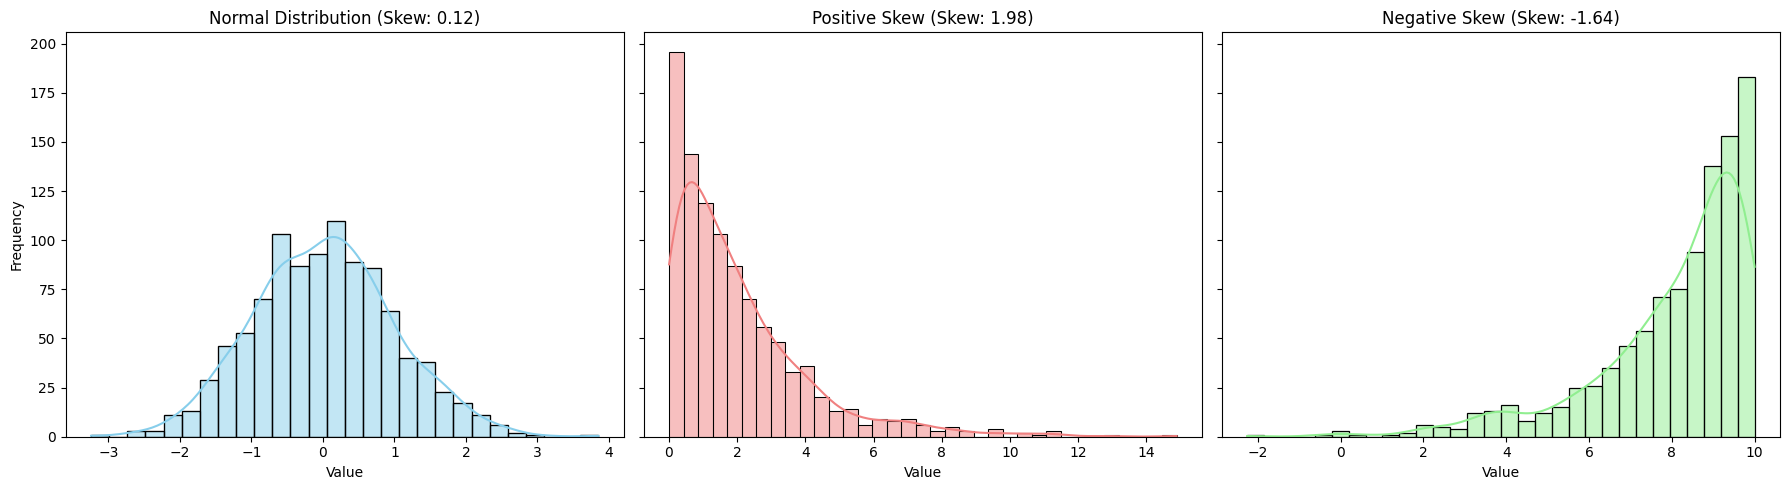

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

sns.histplot(df_skew['Normal'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title(f'Normal Distribution (Skew: {df_skew["Normal"].skew():.2f})')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Frequency')

sns.histplot(df_skew['Positive_Skew'], kde=True, ax=axes[1], color='lightcoral')
axes[1].set_title(f'Positive Skew (Skew: {df_skew["Positive_Skew"].skew():.2f})')
axes[1].set_xlabel('Value')

sns.histplot(df_skew['Negative_Skew'], kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title(f'Negative Skew (Skew: {df_skew["Negative_Skew"].skew():.2f})')
axes[2].set_xlabel('Value')

plt.tight_layout()
plt.show()

The histograms and KDE plots visually represent the three types of skewness: the symmetrical bell shape of the normal distribution, the long tail to the right for positive skew, and the long tail to the left for negative skew.

### Diagnosis

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, norm

# Using the simulated df_skew from the Demonstration section

print("1. Visual Inspection (Histograms/KDEs): Already done in the Diagram section.")

print("\n2. Skewness Coefficients:")
for col in df_skew.columns:
    print(f"  {col} Skewness: {df_skew[col].skew():.3f}")

print("\nInterpretation:")
print("  - Skewness close to 0: Approximately symmetric (e.g., Normal).")
print("  - Skewness > 0 (e.g., > 0.5 or > 1.0 depending on context): Positive skew (right tail).")
print("  - Skewness < 0 (e.g., < -0.5 or < -1.0 depending on context): Negative skew (left tail).")

print("\n3. Comparison of Mean and Median:")
for col in df_skew.columns:
    mean_val = df_skew[col].mean()
    median_val = df_skew[col].median()
    print(f"  {col}: Mean = {mean_val:.3f}, Median = {median_val:.3f}")
    if mean_val > median_val:
        print(f"    Mean > Median, suggesting positive skew.")
    elif mean_val < median_val:
        print(f"    Mean < Median, suggesting negative skew.")
    else:
        print(f"    Mean = Median, suggesting symmetry.")

print("\n4. Statistical Tests (e.g., D'Agostino's K-squared test for normality, which includes skewness):")
from scipy.stats import kstest, shapiro, normaltest

# Shapiro-Wilk Test for normality (null hypothesis: data is normal)
print("\nShapiro-Wilk Test for Normality (P-value < 0.05 implies non-normal):")
for col in df_skew.columns:
    stat, p = shapiro(df_skew[col])
    print(f"  {col}: Statistic={stat:.3f}, P-value={p:.3f}")
    if p < 0.05:
        print(f"    Reject H0, {col} is likely non-normal (possibly due to skewness).")
    else:
        print(f"    Fail to reject H0, {col} appears normal.")


1. Visual Inspection (Histograms/KDEs): Already done in the Diagram section.

2. Skewness Coefficients:
  Normal Skewness: 0.117
  Positive_Skew Skewness: 1.984
  Negative_Skew Skewness: -1.638

Interpretation:
  - Skewness close to 0: Approximately symmetric (e.g., Normal).
  - Skewness > 0 (e.g., > 0.5 or > 1.0 depending on context): Positive skew (right tail).
  - Skewness < 0 (e.g., < -0.5 or < -1.0 depending on context): Negative skew (left tail).

3. Comparison of Mean and Median:
  Normal: Mean = 0.019, Median = 0.025
    Mean < Median, suggesting negative skew.
  Positive_Skew: Mean = 2.016, Median = 1.452
    Mean > Median, suggesting positive skew.
  Negative_Skew: Mean = 8.053, Median = 8.647
    Mean < Median, suggesting negative skew.

4. Statistical Tests (e.g., D'Agostino's K-squared test for normality, which includes skewness):

Shapiro-Wilk Test for Normality (P-value < 0.05 implies non-normal):
  Normal: Statistic=0.999, P-value=0.627
    Fail to reject H0, Normal app

Skewness can be diagnosed by visual inspection of histograms or KDE plots, by calculating the skewness coefficient, and by comparing the mean and median of the distribution. Statistical tests for normality, such as the Shapiro-Wilk test, can also indirectly indicate significant skewness if the null hypothesis of normality is rejected.

### Damage
Skewed data can severely impact statistical models that assume normally distributed errors or symmetric predictor variables, such as linear regression. It can lead to biased or inefficient parameter estimates, incorrect standard errors, and invalid hypothesis tests. For instance, in financial data, positively skewed returns (more frequent small losses, rare large gains) or negatively skewed returns (more frequent small gains, rare large losses) can mislead risk assessments and portfolio optimization strategies if not properly accounted for.

### Directions
1.  **Data Transformations**: Apply mathematical transformations to reduce skewness and make the distribution more symmetrical. Common transformations include:
    *   **Log Transformation**: For positively skewed data, especially when values are strictly positive. ($ \log(X) $ or $ \log(X+c) $).
    *   **Square Root Transformation**: For moderately positively skewed data. ($ \sqrt{X} $).
    *   **Reciprocal Transformation**: Can be used for highly positively skewed data, but reverses the order of values. ($ 1/X $).
    *   **Box-Cox Transformation**: A more general power transformation that can handle various types of skewness ($ (X^\lambda - 1) / \lambda $). It automatically determines the optimal $ \lambda $.
    *   **Exponential Transformation**: For negatively skewed data. ($ e^X $).
2.  **Non-parametric Models**: Use models that do not assume specific data distributions, such as decision trees, random forests, or gradient boosting machines.
3.  **Robust Statistical Methods**: Employ methods that are less sensitive to departures from normality, such as robust regression.
4.  **Discretization/Binning**: Convert continuous skewed variables into categorical bins, if appropriate for the analysis.
5.  **Use Median Instead of Mean**: For skewed distributions, the median is often a more robust measure of central tendency than the mean, especially for reporting descriptive statistics.

In [1]:
import kagglehub
path = kagglehub.dataset_download("riturajdutta/kagglejson")

100%|██████████| 229/229 [00:00<00:00, 539kB/s]

Extracting files...


## 4. Sensitivity to Outliers

### Definition
Sensitivity to outliers refers to the extent to which the parameters or predictions of a statistical model are affected by the presence of extreme data points (outliers). An outlier is an observation point that is distant from other observations. In regression analysis, a single outlier can significantly alter the estimated coefficients, inflate standard errors, and mislead statistical inference.

### Description
Models sensitive to outliers can yield misleading results because a few unusual data points can disproportionately influence the model's structure. This can lead to inaccurate predictions, incorrect conclusions about relationships between variables, and poor generalization performance, especially when such outliers are merely noise or errors.

### Demonstration

In [14]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# Simulate data with a linear relationship
np.random.seed(42)
num_samples = 50
X = np.random.rand(num_samples) * 10
Y = 2 * X + 5 + np.random.randn(num_samples) * 2

# Introduce an outlier
X_outlier = np.append(X, 9.5) # x-value close to the end of the range
Y_outlier = np.append(Y, 40)  # y-value significantly higher than expected

df_original = pd.DataFrame({'X': X, 'Y': Y})
df_with_outlier = pd.DataFrame({'X': X_outlier, 'Y': Y_outlier})

# Fit a linear regression model to the original data
X_const_orig = sm.add_constant(df_original['X'])
model_original = sm.OLS(df_original['Y'], X_const_orig)
results_original = model_original.fit()

print("\nRegression results for Original Data (No Outlier):")
print(results_original.summary())

# Fit a linear regression model to the data with an outlier
X_const_outlier = sm.add_constant(df_with_outlier['X'])
model_outlier = sm.OLS(df_with_outlier['Y'], X_const_outlier)
results_outlier = model_outlier.fit()

print("\nRegression results for Data WITH Outlier:")
print(results_outlier.summary())


Regression results for Original Data (No Outlier):
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.905
Model:                            OLS   Adj. R-squared:                  0.903
Method:                 Least Squares   F-statistic:                     455.9
Date:                Wed, 06 May 2026   Prob (F-statistic):           3.75e-26
Time:                        11:05:29   Log-Likelihood:                -100.74
No. Observations:                  50   AIC:                             205.5
Df Residuals:                      48   BIC:                             209.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------


Notice how the estimated coefficients (especially for `X`) and the R-squared value change significantly with the inclusion of just one outlier. The standard errors can also be inflated, making the model less reliable.

### Diagram

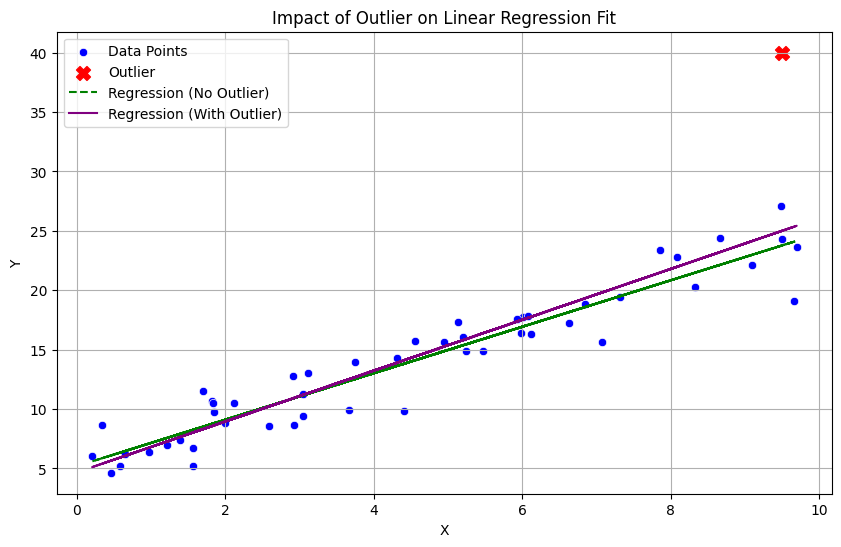

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_with_outlier['X'], y=df_with_outlier['Y'], color='blue', label='Data Points')
plt.scatter(X_outlier[-1], Y_outlier[-1], color='red', s=100, marker='X', label='Outlier') # Highlight the outlier

# Plot regression line for original data
plt.plot(df_original['X'], results_original.predict(X_const_orig), color='green', linestyle='--', label='Regression (No Outlier)')

# Plot regression line for data with outlier
plt.plot(df_with_outlier['X'], results_outlier.predict(X_const_outlier), color='purple', linestyle='-', label='Regression (With Outlier)')

plt.title('Impact of Outlier on Linear Regression Fit')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()

The diagram clearly shows how the single outlier pulls the regression line significantly towards itself, altering the slope and intercept from the original, true relationship.

### Diagnosis

1. Visual Inspection (Scatter Plots/Box Plots): Done in Diagram section.

2. Residual Plots:


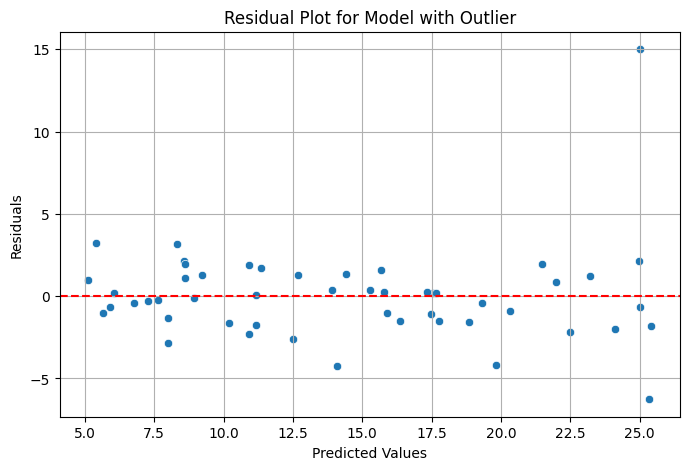


Interpretation: Outliers often appear as points far from the bulk of the residuals, or as points with very large residuals.

3. Influence Measures (Cook's Distance, DFFITS, DFBETAS):


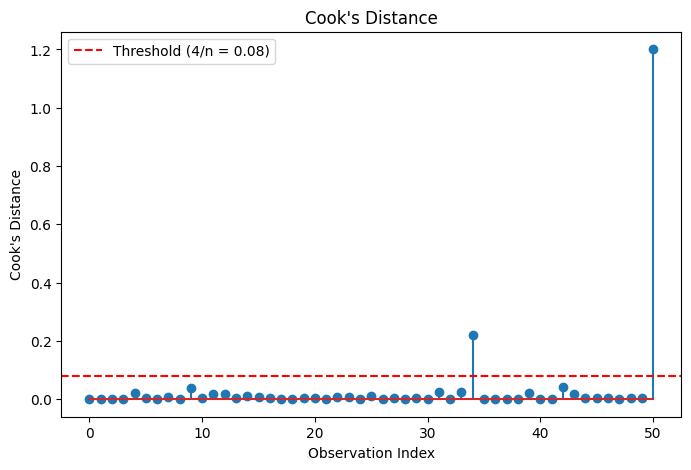


Interpretation: High Cook's Distance values (often > 4/n or 1) indicate influential points.
Max Cook's Distance: 1.201 at index 50


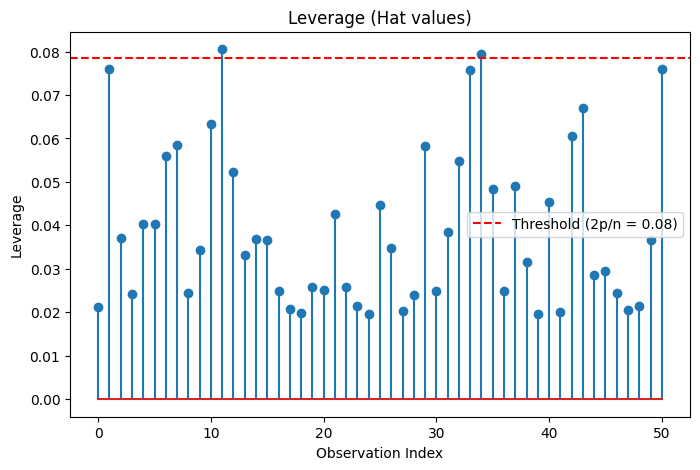


Interpretation: High leverage points (often > 2p/n, where p is number of params and n is number of obs) are unusual in X-space.
Max Leverage: 0.081 at index 11


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import OLSInfluence

# Ensure df_with_outlier is defined from the Demonstration cell above.

print("1. Visual Inspection (Scatter Plots/Box Plots): Done in Diagram section.")

print("\n2. Residual Plots:")
# Calculate residuals for the model with outlier
residuals = results_outlier.resid
predicted_values = results_outlier.predict(X_const_outlier)

plt.figure(figsize=(8, 5))
sns.scatterplot(x=predicted_values, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residual Plot for Model with Outlier')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

print("\nInterpretation: Outliers often appear as points far from the bulk of the residuals, or as points with very large residuals.")

print("\n3. Influence Measures (Cook's Distance, DFFITS, DFBETAS):")
# Calculate influence measures
infl = OLSInfluence(results_outlier)

# Cook's Distance
cook_distance = infl.cooks_distance[0]
plt.figure(figsize=(8, 5))
plt.stem(np.arange(len(cook_distance)), cook_distance)
plt.title("Cook's Distance")
plt.xlabel('Observation Index')
plt.ylabel("Cook's Distance")
plt.axhline(y=4/len(cook_distance), color='r', linestyle='--', label=f"Threshold (4/n = {4/len(cook_distance):.2f})")
plt.legend()
plt.show()

print("\nInterpretation: High Cook's Distance values (often > 4/n or 1) indicate influential points.")
print(f"Max Cook's Distance: {np.max(cook_distance):.3f} at index {np.argmax(cook_distance)}")

# Leverage (Hat values)
leverage = infl.hat_matrix_diag
plt.figure(figsize=(8, 5))
plt.stem(np.arange(len(leverage)), leverage)
plt.title("Leverage (Hat values)")
plt.xlabel('Observation Index')
plt.ylabel('Leverage')
plt.axhline(y=2*(len(results_outlier.params))/len(leverage), color='r', linestyle='--', label=f"Threshold (2p/n = {2*(len(results_outlier.params))/len(leverage):.2f})")
plt.legend()
plt.show()

print("\nInterpretation: High leverage points (often > 2p/n, where p is number of params and n is number of obs) are unusual in X-space.")
print(f"Max Leverage: {np.max(leverage):.3f} at index {np.argmax(leverage)}")

Outliers can be diagnosed visually using scatter plots or box plots. More formally, residual plots reveal points with large errors, and influence measures like Cook's Distance quantify how much a single observation influences the overall model. High leverage values indicate observations unusual in the predictor space.

### Damage
The damage from sensitivity to outliers includes biased parameter estimates, inflated standard errors leading to incorrect statistical inference (e.g., misjudging significance of variables), decreased model accuracy, and reduced generalization capability. In financial modeling, this could lead to suboptimal portfolio allocation, inaccurate risk assessments, or failed trading strategies based on models that are unduly influenced by rare events.

### Directions
1.  **Outlier Detection and Removal/Transformation**: Identify outliers using visual methods (box plots, scatter plots) or statistical tests (Z-score, IQR rule, Isolation Forest). Depending on the nature of the outlier (data entry error vs. true extreme event), consider removing it, transforming the data (e.g., log transform for skewed data), or winsorizing/trimming.
2.  **Robust Regression Methods**: Use regression techniques that are less sensitive to outliers, such as:
    *   **Huber Regression**: Combines the benefits of least squares and least absolute deviations. It is quadratic for small residuals and linear for large residuals.
    *   **RANSAC (RANdom SAmple Consensus)**: Iteratively fits models to subsets of data and selects the model that has the most inliers.
    *   **Theil-Sen Estimator**: A non-parametric method that computes the median of the slopes of all lines through pairs of points.
3.  **Median-based Statistics**: For descriptive statistics, use the median instead of the mean, as the median is less affected by extreme values.
4.  **Ensemble Methods**: Tree-based ensemble methods like Random Forests and Gradient Boosting Machines are generally more robust to outliers as they rely on decision rules rather than distance-based metrics.
5.  **Data Collection and Domain Knowledge**: Investigate outliers to understand their cause. They might be measurement errors, data entry mistakes, or genuinely rare but important events. Domain expertise is crucial to decide how to treat them.

## Summary

This handbook has explored four critical challenges in time series modeling, particularly relevant to financial volatility analysis: Multicollinearity, Overfitting, Skewness, and Sensitivity to Outliers. For each problem, we provided a technical definition, a descriptive explanation, numerical demonstrations, visual diagrams, diagnostic methods, discussed the potential damage, and offered practical mitigation strategies.

*   **Multicollinearity** refers to high correlation among predictor variables, leading to unstable and uninterpretable regression coefficients. Diagnosis typically involves VIF and correlation matrices, with solutions including variable removal, combination, regularization, or PCA.
*   **Overfitting** occurs when a model learns the training data too well, failing to generalize to new data. It is identified by a significant divergence between training and test performance, and mitigated by model simplification, regularization, cross-validation, early stopping, or increasing data.
*   **Skewness** describes the asymmetry of a data distribution. Skewed data can bias models that assume normality. Diagnosis involves skewness coefficients, mean/median comparison, and visual inspection, with mitigation through data transformations (e.g., log, Box-Cox) or robust models.
*   **Sensitivity to Outliers** highlights how extreme data points can disproportionately influence model parameters, leading to inaccurate results. Outliers are diagnosed via visual plots and influence measures (e.g., Cook's Distance), and addressed using robust regression methods, outlier removal/transformation, or median-based statistics.

## References

*   Dougherty, C. (2011) *Introduction to Econometrics*. 4th ed. Oxford: Oxford University Press.
*   James, G., Witten, D., Hastie, T. and Tibshirani, R. (2013) *An Introduction to Statistical Learning with Applications in R*. New York: Springer.
*   Montgomery, D.C., Peck, E.A. and Vining, G.G. (2012) *Introduction to Linear Regression Analysis*. 5th ed. Hoboken, NJ: John Wiley & Sons.
*   Shapiro, S.S. and Wilk, M.B. (1965) 'An analysis of variance test for normality (complete samples)', *Biometrika*, 52(3/4), pp. 591–611.